In [1]:
import os
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Setup directory paths (using current working directory for Jupyter)
notebook_dir = os.getcwd()
root_dir=os.path.dirname(os.path.dirname(notebook_dir))

output_dir = os.path.join(root_dir, "output", "sh-02-carryforward")
file_path = os.path.join(root_dir, "raw_data", "SH-02 CARRY FORWARD 24022025.parquet")

print(f"Target file path: {file_path}")
print(f"Output directory: {output_dir}")

Target file path: c:\Users\Aditya Singh\Desktop\INTERN\raw_data\SH-02 CARRY FORWARD 24022025.parquet
Output directory: c:\Users\Aditya Singh\Desktop\INTERN\output\sh-02-carryforward


In [2]:
print(f"Reading and downsampling data from {file_path}")
print("Processing in chunks with vectorized downsampling...")

parquet_file = pq.ParquetFile(file_path)
downsampled_chunks = []
global_row_count = 0

# Process in batches of 10,000 rows
for batch in parquet_file.iter_batches(batch_size=10000):
    df_chunk = batch.to_pandas()
    chunk_len = len(df_chunk)
    
    # Calculate the exact starting index for this chunk to maintain the global "every 100th row" rule
    remainder = global_row_count % 100
    start_idx = 0 if remainder == 0 else (100 - remainder)
    
    if start_idx < chunk_len:
        # Slicing with [start::100] is fully vectorized and incredibly fast
        downsampled_chunks.append(df_chunk.iloc[start_idx::100].copy())
        
    global_row_count += chunk_len
    print(f"Processed {global_row_count} rows...", end='\r')
    
print(f"\nFinished reading. Concatenating chunks...")
df_down = pd.concat(downsampled_chunks, ignore_index=True)
print(f"Downsampled dataframe shape: {df_down.shape}")

# Ensure Timestamp is handled correctly
if 'Timestamp' in df_down.columns:
    df_down['Timestamp'] = pd.to_datetime(df_down['Timestamp'])
    print("Timestamp column successfully converted to datetime.")

Reading and downsampling data from c:\Users\Aditya Singh\Desktop\INTERN\raw_data\SH-02 CARRY FORWARD 24022025.parquet
Processing in chunks with vectorized downsampling...
Processed 420000 rows...
Finished reading. Concatenating chunks...
Downsampled dataframe shape: (4200, 10646)
Timestamp column successfully converted to datetime.


In [3]:
print("Pre-calculating standard deviations for all columns...")
# Convert bools to float for unified std calculation; non-numeric columns will be ignored here
numeric_bool_df = df_down.select_dtypes(include=[np.number, 'bool'])
stds = numeric_bool_df.astype(float).std().fillna(0)
print("Standard deviations calculated successfully.")

Pre-calculating standard deviations for all columns...
Standard deviations calculated successfully.


In [4]:
# ================================================================
# COBBLE DETECTION ANALYSIS
# ================================================================
print("\n" + "=" * 70)
print("COBBLE DETECTION ANALYSIS")
print("=" * 70)

# The 24 cobble detection columns (one per stand)
cobble_cols = [
    f'[13_{87 + i}]STD{str(i + 1).zfill(2)} COBBLE DETECTED (TRACKING)'
    for i in range(24)
]

# Check which cobble columns exist in the downsampled data
cobble_present = [c for c in cobble_cols if c in df_down.columns]
cobble_missing = [c for c in cobble_cols if c not in df_down.columns]

print(f"\nCobble columns found: {len(cobble_present)} / 24")
if cobble_missing:
    print(f"Cobble columns missing: {len(cobble_missing)}")

# Check each stand for cobble events
total_cobble_rows = 0
stands_with_cobble = []

print(f"\n{'Stand':<10} {'Cobble Rows':<15} {'% of Data':<12} {'First Row':<12} {'Last Row':<12}")
print("-" * 61)

for col in cobble_present:
    # Extract stand name
    stand = col.split(']')[1].split(' ')[0]  # e.g., "STD05"

    # Count rows where cobble = True
    cobble_mask = df_down[col].astype(bool)
    n_cobble = cobble_mask.sum()

    if n_cobble > 0:
        first_row = cobble_mask.idxmax()
        last_row = len(cobble_mask) - 1 - cobble_mask[::-1].idxmax()
        pct = 100 * n_cobble / len(df_down)
        print(f"{stand:<10} {n_cobble:<15} {pct:<12.2f} {first_row:<12} {last_row:<12}")
        stands_with_cobble.append(stand)
        total_cobble_rows = max(total_cobble_rows, n_cobble)
    else:
        pass  # Skip stands with no cobble (keeps output clean)

# Overall summary
any_cobble = df_down[cobble_present].astype(bool).any(axis=1)
total_any = any_cobble.sum()

print("-" * 61)
print(f"\nSUMMARY:")
print(f"  Total rows in downsampled data:    {len(df_down):,}")
print(f"  Rows with cobble (any stand):      {total_any:,}")
print(f"  Rows without cobble:               {len(df_down) - total_any:,}")
print(f"  Cobble percentage:                 {100 * total_any / len(df_down):.2f}%")
print(f"  Stands affected by cobble:         {len(stands_with_cobble)}")
if stands_with_cobble:
    print(f"  Affected stands:                   {', '.join(stands_with_cobble)}")

# Find cobble onset (first row where ANY stand detects cobble)
if total_any > 0:
    onset_idx = any_cobble.idxmax()
    # If we have timestamps
    if 'Timestamp' in df_down.columns:
        onset_time = df_down.loc[onset_idx, 'Timestamp']
        print(f"  Cobble onset (downsampled row):    {onset_idx}")
        print(f"  Cobble onset (timestamp):          {onset_time}")
    else:
        print(f"  Cobble onset (downsampled row):    {onset_idx}")

    # Count distinct cobble "events" (separated by gaps of >10 rows of no-cobble)
    cobble_indices = any_cobble[any_cobble].index.to_numpy()
    gaps = np.diff(cobble_indices)
    n_events = 1 + (gaps > 10).sum()  # new event if gap > 10 seconds
    print(f"\n  Number of distinct cobble events:  {n_events}")
    print(f"  (Events separated by gaps of >10 seconds of no-cobble)")
else:
    print(f"\n  *** NO COBBLE EVENTS DETECTED IN THIS DATASET ***")

print("=" * 70)


COBBLE DETECTION ANALYSIS

Cobble columns found: 24 / 24

Stand      Cobble Rows     % of Data    First Row    Last Row    
-------------------------------------------------------------
STD12      178             4.24         2122         1785        
STD13      178             4.24         2122         1785        
-------------------------------------------------------------

SUMMARY:
  Total rows in downsampled data:    4,200
  Rows with cobble (any stand):      178
  Rows without cobble:               4,022
  Cobble percentage:                 4.24%
  Stands affected by cobble:         2
  Affected stands:                   STD12, STD13
  Cobble onset (downsampled row):    2122
  Cobble onset (timestamp):          2025-02-24 10:40:57.010000

  Number of distinct cobble events:  3
  (Events separated by gaps of >10 seconds of no-cobble)


In [5]:
print("Identifying column types (Boolean, Constant, Analog)...")
constant_cols = []
bool_cols = []
analog_cols = []

# Process numeric/boolean columns based on pre-calculated stds
for col in df_down.columns:
    if col in stds.index:
        col_std = stds[col]
        if col_std == 0:
            constant_cols.append(col)
        elif pd.api.types.is_bool_dtype(df_down[col]):
            bool_cols.append(col)
        else:
            # Fast check for 0/1 columns using downsampled data
            unique_vals = set(df_down[col].dropna().unique())
            if unique_vals.issubset({0, 1, 0.0, 1.0}):
                bool_cols.append(col)
            else:
                analog_cols.append(col)
    else:
        # Handle non-numeric columns (e.g., strings/objects)
        if df_down[col].nunique(dropna=False) <= 1:
            constant_cols.append(col)
        else:
            analog_cols.append(col)

print(f"Found {len(bool_cols)} boolean, {len(constant_cols)} constant, and {len(analog_cols)} analog columns.")

Identifying column types (Boolean, Constant, Analog)...
Found 1313 boolean, 7963 constant, and 1370 analog columns.


In [6]:
def sort_cols_by_std(cols):
    col_stds = {c: stds[c] if c in stds.index else 0 for c in cols}
    return sorted(col_stds, key=col_stds.get, reverse=True)

print("Sorting columns by standard deviation (high fluctuation to low)...")
sorted_bool = sort_cols_by_std(bool_cols)
sorted_analog = sort_cols_by_std(analog_cols)
sorted_const = sort_cols_by_std(constant_cols)

print("Saving categorized datasets to CSV...")
# Updated saving paths to output_dir
df_down[sorted_bool].to_csv(os.path.join(output_dir, "boolean_columns.csv"), index=False)
df_down[sorted_analog].to_csv(os.path.join(output_dir, "analog_columns.csv"), index=False)
df_down[sorted_const].to_csv(os.path.join(output_dir, "constant_columns.csv"), index=False)
print(f"Categorized CSVs saved successfully to {output_dir}")

Sorting columns by standard deviation (high fluctuation to low)...
Saving categorized datasets to CSV...
Categorized CSVs saved successfully to c:\Users\Aditya Singh\Desktop\INTERN\output\sh-02-carryforward


In [7]:
print("Extracting specific parameters (Speed, Torque, Current, Power, Looper, Vibration)...")
param_keywords = {
    'speed': ['speed'],
    'torque': ['torque'],
    'current': ['current'],
    'power': ['power'],
    'looper': ['loop', 'l1112', 'l1213', 'l1314', 'l1415', 'l1516', 'l1617', 'l1718', 'l1819', 'l1920', 'l2021', 'l24fb'],
    'vibration': ['vib'] # Updated keyword from 'vibr' to 'vib'
}

params_cols = {k: [] for k in param_keywords.keys()}
all_cols_lower = {str(col).lower(): col for col in df_down.columns}

# Vector-like matching using dictionary lookups
for col_lower, original_col in all_cols_lower.items():
    for param, keywords in param_keywords.items():
        if any(kw in col_lower for kw in keywords):
            params_cols[param].append(original_col)

all_param_cols = list(set().union(*params_cols.values()))

# Add Timestamp to the front of all_parameters if it exists
if 'Timestamp' in df_down.columns and 'Timestamp' not in all_param_cols:
    all_param_cols.insert(0, 'Timestamp')

print(f"Found {len(all_param_cols)} columns across all specified parameters.")
df_down[all_param_cols].to_csv(os.path.join(output_dir, "all_parameters.csv"), index=False)

Extracting specific parameters (Speed, Torque, Current, Power, Looper, Vibration)...
Found 967 columns across all specified parameters.


In [8]:
print("Finding highest standard deviation column for each parameter...")
highest_cols = []
for param, cols in params_cols.items():
    if not cols:
        print(f"  {param}: No columns found.")
        continue
    
    param_stds = {c: stds[c] if c in stds.index else 0 for c in cols}
    highest_col = max(param_stds, key=param_stds.get)
    highest_val = param_stds[highest_col]
    
    print(f"  {param}: {highest_col} (std = {highest_val:.4f})")
    highest_cols.append(highest_col)

# Ensure Timestamp accompanies highest columns output
output_cols = list(highest_cols)
if 'Timestamp' in df_down.columns:
    output_cols.insert(0, 'Timestamp')

print("\nSaving highest fluctuation dataset...")
df_down[output_cols].to_csv(os.path.join(output_dir, "highest_std_parameters.csv"), index=False)

Finding highest standard deviation column for each parameter...
  speed: [14:23]Drive Fbk Speed PR002 (std = 7136.9592)
  torque: [19:57]PR003: Drive - Reference Torque Positive (std = 1843.4015)
  current: [6:97]S120_1A21PN010_IDB_KICK_OFF_4_DIN_CURRENT (std = 2178.5223)
  power: [7:51]CZ75 COA Fan 02 Drv Power Count Val (std = 1183.1528)
  looper: [17:24]Loop Height ANALOGUE L1415 (std = 8375.6828)
  vibration: [12:112]CZ75_SNS_VT75_21_CA_FAN2_VIB (std = 307.3593)

Saving highest fluctuation dataset...


In [9]:
def normalize_series(series):
    """Scales a pandas Series strictly between 0 and 1."""
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return series * 0.0  # Avoid division by zero if the column is constant
    return (series - min_val) / (max_val - min_val)

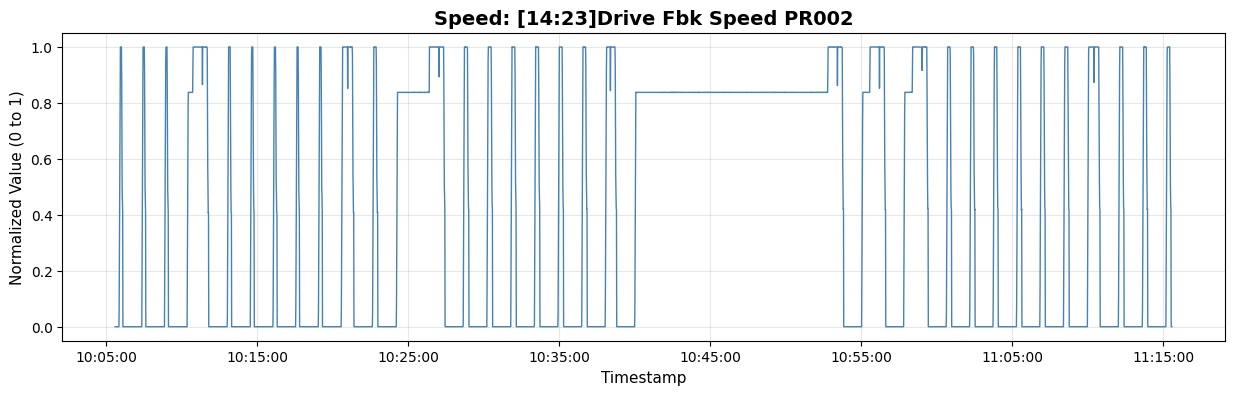

In [10]:
param = 'speed'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)

    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], normalize_series(df_down[col]), linewidth=1, color='steelblue')
    plt.title(f"Speed: {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_plot.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No data found for {param}")

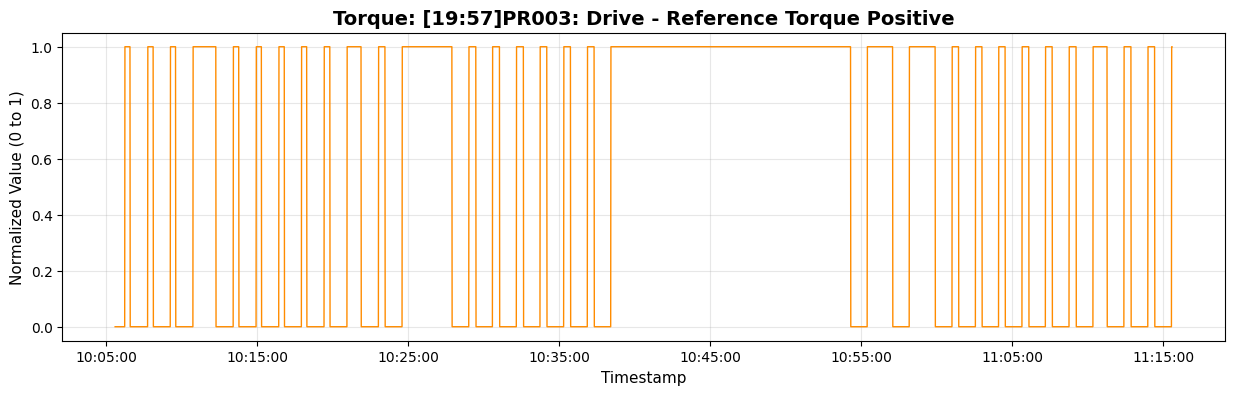

In [11]:
param = 'torque'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)
    
    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], normalize_series(df_down[col]), linewidth=1, color='darkorange')
    plt.title(f"Torque: {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_plot.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No data found for {param}")

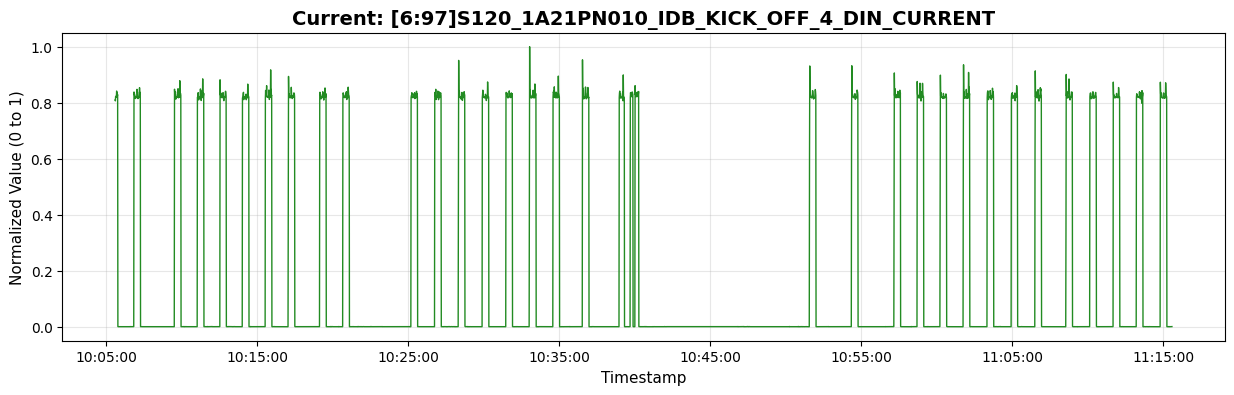

In [12]:
param = 'current'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)
    
    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], normalize_series(df_down[col]), linewidth=1, color='forestgreen')
    plt.title(f"Current: {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_plot.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No data found for {param}")

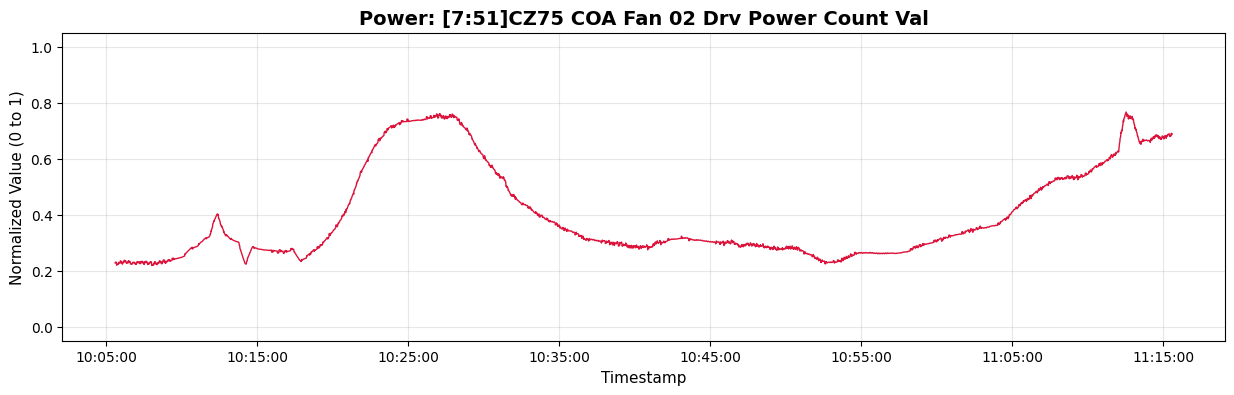

In [13]:
param = 'power'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)

    
    norm_series = normalize_series(df_down[col])
    smoothed_series = norm_series.rolling(window=30, min_periods=1, center=True).mean()
    
    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], smoothed_series, linewidth=1, color='crimson')
    plt.title(f"Power: {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_plot.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No data found for {param}")

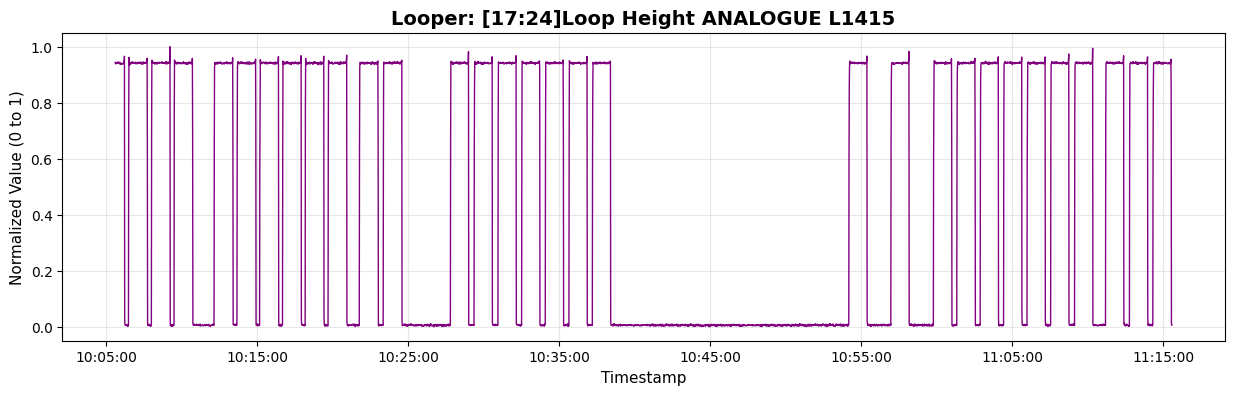

In [14]:
param = 'looper'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)
    
    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], normalize_series(df_down[col]), linewidth=1, color='purple')
    plt.title(f"Looper: {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_plot.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No data found for {param}")

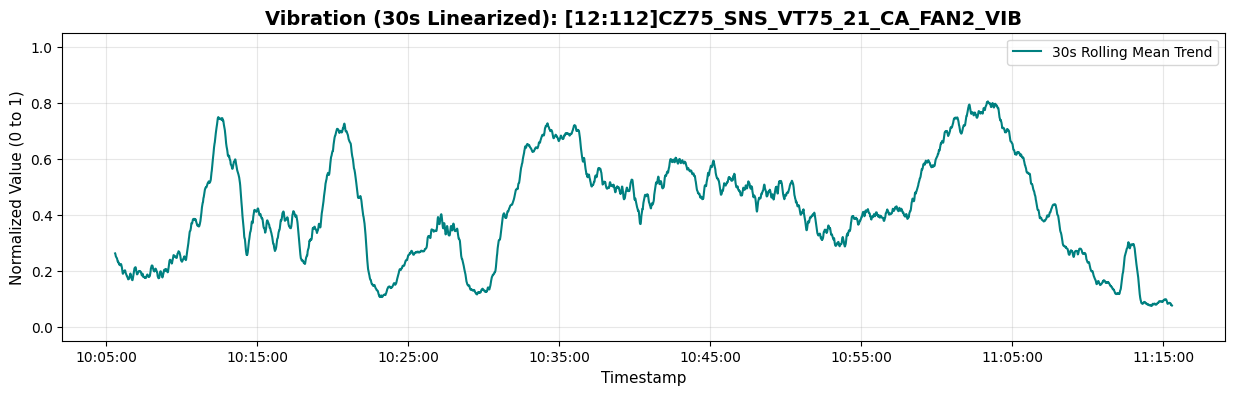

In [15]:
param = 'vibration'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)
    
    # 1. Normalize original series
    norm_series = normalize_series(df_down[col])
    
    # 2. Linearize/smooth trends over a 30-second rolling window
    smoothed_series = norm_series.rolling(window=30, min_periods=1, center=True).mean()
    
    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], smoothed_series, linewidth=1.5, color='teal', label='30s Rolling Mean Trend')
    plt.title(f"Vibration (30s Linearized): {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_trend_plot.png"), dpi=150, bbox_inches='tight')
    plt.legend()
    plt.show()
else:
    print(f"No data found for {param}")

In [16]:
param = 'speed'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: SPEED ===
01. Std Dev: 7136.9592 -> [14:23]Drive Fbk Speed PR002
02. Std Dev: 6224.3968 -> [14:22]Drive Fbk Speed PR001
03. Std Dev: 5249.3389 -> [6:32]FERT_SEC1_DRV_IDB_DIN_SPEED
04. Std Dev: 4516.0742 -> [14:214]Drive Speed Reference PR001
05. Std Dev: 4144.8359 -> [14:21]Drive Fbk Speed EXFRT_S2
06. Std Dev: 4071.9736 -> [14:215]Drive Speed Reference PR002
07. Std Dev: 4020.1011 -> [14:24]Drive Fbk Speed INSRT_S1
08. Std Dev: 4020.1011 -> [14:25]Drive Fbk Speed INSRT_S2
09. Std Dev: 3551.2859 -> [6:38]S120_1A21PN002_IDB_FUR_CHRG_RT_DIN_SPEED
10. Std Dev: 3281.8315 -> [14:213]Drive Speed Reference EXFRT_S2
11. Std Dev: 3036.2324 -> [14:217]Drive Speed Reference INSRT_S2
12. Std Dev: 2919.7498 -> [14:216]Drive Speed Reference INSRT_S1
13. Std Dev: 2725.6752 -> [6:44]S120_1A21PN011_IDB_FUR_DHG_RT_DIN_SPEED
14. Std Dev: 2449.1759 -> [6:96]S120_1A21PN010_IDB_KICK_OFF_4_DIN_SPEED
15. Std Dev: 2445.4931 -> [6:88]S120_1A21PN009_IDB_KICK_OFF_3_DIN_SPE

In [17]:
param = 'torque'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: TORQUE ===
01. Std Dev: 1843.4015 -> [19:57]PR003: Drive - Reference Torque Positive
02. Std Dev: 1843.4015 -> [19:58]PR003: Drive - Reference Torque Negative
03. Std Dev: 1253.0075 -> [6:58]S120_1A21PN004_IDB_KICK_IN_ARM_02_DIN_TORQUE
04. Std Dev: 1009.9068 -> [6:40]S120_1A21PN002_IDB_FUR_CHRG_RT_DIN_TORQUE
05. Std Dev: 921.3278 -> [6:46]S120_1A21PN011_IDB_FUR_DHG_RT_DIN_TORQUE
06. Std Dev: 910.4085 -> [6:72]S120_1A21PN006_IDB_KICK_IN_ARM_04_DIN_TORQUE
07. Std Dev: 787.1905 -> [6:34]FERT_SEC1_DRV_IDB_DIN_TORQUE
08. Std Dev: 772.5636 -> [6:52]S120_1A21PN003_IDB_KICK_IN_ARM_01_DIN_TORQUE
09. Std Dev: 757.4464 -> [6:66]S120_1A21PN005_IDB_KICK_IN_ARM_03_DIN_TORQUE
10. Std Dev: 31.7077 -> [14:94]Drive Fbk Torque SH001
11. Std Dev: 31.3606 -> [14:78]Drive Fbk Torque STD15
12. Std Dev: 31.3226 -> [13:46]STD15 - Load Torque DTC Filtered
13. Std Dev: 31.3222 -> [16:78]Load In Torque STD15
14. Std Dev: 31.3205 -> [13:14]STD15 - T FBK Torque Norm
15. Std 

In [18]:
param = 'current'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: CURRENT ===
01. Std Dev: 2178.5223 -> [6:97]S120_1A21PN010_IDB_KICK_OFF_4_DIN_CURRENT
02. Std Dev: 2080.1528 -> [6:39]S120_1A21PN002_IDB_FUR_CHRG_RT_DIN_CURRENT
03. Std Dev: 1995.3372 -> [6:65]S120_1A21PN005_IDB_KICK_IN_ARM_03_DIN_CURRENT
04. Std Dev: 1921.5501 -> [6:51]S120_1A21PN003_IDB_KICK_IN_ARM_01_DIN_CURRENT
05. Std Dev: 1901.7342 -> [6:33]FERT_SEC1_DRV_IDB_DIN_CURRENT
06. Std Dev: 1857.6684 -> [6:57]S120_1A21PN004_IDB_KICK_IN_ARM_02_DIN_CURRENT
07. Std Dev: 1850.9355 -> [6:71]S120_1A21PN006_IDB_KICK_IN_ARM_04_DIN_CURRENT
08. Std Dev: 1683.8928 -> [6:45]S120_1A21PN011_IDB_FUR_DHG_RT_DIN_CURRENT
09. Std Dev: 506.6099 -> [2:297]PLC01_HMI_STATUS_DCBUS_STATUS_SLM1_LINEUP2_LINE_CURRENT
10. Std Dev: 494.8934 -> [2:301]PLC01_HMI_STATUS_DCBUS_STATUS_SLM3_LINEUP2_LINE_CURRENT
11. Std Dev: 453.0968 -> [2:305]PLC01_HMI_STATUS_DCBUS_STATUS_SLM1_LINEUP3_LINE_CURRENT
12. Std Dev: 449.4278 -> [2:309]PLC01_HMI_STATUS_DCBUS_STATUS_SLM3_LINEUP3_LINE_CURREN

In [19]:
param = 'power'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: POWER ===
01. Std Dev: 1183.1528 -> [7:51]CZ75 COA Fan 02 Drv Power Count Val
02. Std Dev: 1039.3971 -> [19:35]PR003: Drive - Actual Power
03. Std Dev: 661.4666 -> [6:59]S120_1A21PN004_IDB_KICK_IN_ARM_02_DIN_POWER
04. Std Dev: 611.3125 -> [2:296]PLC01_HMI_STATUS_DCBUS_STATUS_SLM1_LINEUP2_POWER
05. Std Dev: 599.8450 -> [2:300]PLC01_HMI_STATUS_DCBUS_STATUS_SLM3_LINEUP2_POWER
06. Std Dev: 579.1627 -> [6:41]S120_1A21PN002_IDB_FUR_CHRG_RT_DIN_POWER
07. Std Dev: 567.5177 -> [6:35]FERT_SEC1_DRV_IDB_DIN_POWER
08. Std Dev: 556.9953 -> [6:47]S120_1A21PN011_IDB_FUR_DHG_RT_DIN_POWER
09. Std Dev: 553.6341 -> [2:304]PLC01_HMI_STATUS_DCBUS_STATUS_SLM1_LINEUP3_POWER
10. Std Dev: 552.1365 -> [2:308]PLC01_HMI_STATUS_DCBUS_STATUS_SLM3_LINEUP3_POWER
11. Std Dev: 510.4326 -> [2:246]PLC01_HMI_STATUS_ENERGY_METER_EM_1A01PN005_APPARENT_POWER
12. Std Dev: 496.1445 -> [2:288]PLC01_HMI_STATUS_DCBUS_STATUS_SLM1_LINEUP1_POWER
13. Std Dev: 492.7981 -> [6:73]S120_1A21PN006_ID

In [20]:
param = 'looper'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: LOOPER ===
01. Std Dev: 8375.6828 -> [17:24]Loop Height ANALOGUE L1415
02. Std Dev: 8052.2913 -> [17:26]Loop Height ANALOGUE L1617
03. Std Dev: 7859.7735 -> [17:31]Loop Height ANALOGUE L24FB
04. Std Dev: 7768.6325 -> [17:21]Loop Height ANALOGUE L1112
05. Std Dev: 7313.8066 -> [17:23]Loop Height ANALOGUE L1314
06. Std Dev: 7296.2922 -> [17:25]Loop Height ANALOGUE L1516
07. Std Dev: 6982.0467 -> [17:22]Loop Height ANALOGUE L1213
08. Std Dev: 4671.4157 -> [17:27]Loop Height ANALOGUE L1718
09. Std Dev: 2899.0770 -> [17:28]Loop Height ANALOGUE L1819
10. Std Dev: 2845.7791 -> [17:29]Loop Height ANALOGUE L1920
11. Std Dev: 104.7933 -> [13:21]L1213 - Actual Height
12. Std Dev: 100.5231 -> [13:20]L1112 - Actual Height
13. Std Dev: 100.1970 -> [13:22]L1314 - Actual Height
14. Std Dev: 100.1581 -> [13:24]L1516 - Actual Height
15. Std Dev: 100.0335 -> [13:23]L1415 - Actual Height
16. Std Dev: 79.5908 -> [13:25]L1617 - Actual Height
17. Std Dev: 77.2352 -> [

In [21]:
param = 'vibration'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: VIBRATION ===
01. Std Dev: 307.3593 -> [12:112]CZ75_SNS_VT75_21_CA_FAN2_VIB
02. Std Dev: 1.1947 -> [12:108]CZ75_SNS_VT75_11_CA_FAN1_VIB
03. Std Dev: 0.2221 -> [9:69]CZ75 COA M75_02 Vib Sns Val
04. Std Dev: 0.0006 -> [9:57]CZ75 COA M75_01 Vib Sns Val
05. Std Dev: 0.0000 -> [7_250]CZ75 COA Fan 01 Vib Trns VT75_11 fail
06. Std Dev: 0.0000 -> [7_251]CZ75 COA Fan 01 Vib Trns VT75_11 High vib wrn
07. Std Dev: 0.0000 -> [7_252]CZ75 COA Fan 01 Vib Trns VT75_11 High vib flt
08. Std Dev: 0.0000 -> [7_282]CZ75 COA Fan 02 Vib Trns VT75_21 fail
09. Std Dev: 0.0000 -> [7_283]CZ75 COA Fan 02 Vib Trns VT75_21 High vib wrn
10. Std Dev: 0.0000 -> [7_284]CZ75 COA Fan 02 Vib Trns VT75_21 High vib flt
